In [1]:
!pip install pandas numpy matplotlib torch fastapi uvicorn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

In [3]:
df = pd.read_excel('Online Retail.xlsx')

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None


In [5]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
df = df.dropna(subset=['CustomerID'])

In [7]:
df = df.drop_duplicates()

In [8]:
df = df[df['Quantity'] > 0]

In [9]:
df = df[df['UnitPrice'] > 0]

In [10]:
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB
None
(392692, 8)


In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [12]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [13]:
daily_sales = (
    df
    .groupby(df['InvoiceDate'].dt.date)['Revenue']
    .sum()
    .reset_index()
)

print(daily_sales.head())

  InvoiceDate   Revenue
0  2010-12-01  46192.49
1  2010-12-02  47197.57
2  2010-12-03  23876.63
3  2010-12-05  31361.28
4  2010-12-06  31009.33


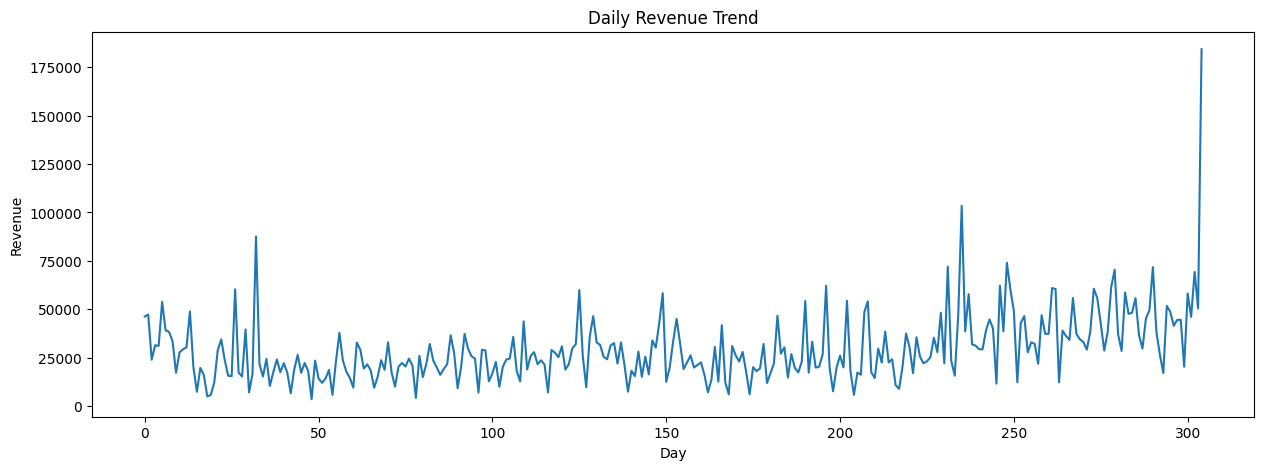

In [14]:
plt.figure(figsize=(15,5))

plt.plot(daily_sales['Revenue'])

plt.title('Daily Revenue Trend')
plt.xlabel('Day')
plt.ylabel('Revenue')

plt.show()

In [15]:
daily_sales['DayIndex'] = np.arange(len(daily_sales))

In [16]:
X = daily_sales[['DayIndex']].values

y = daily_sales['Revenue'].values

In [17]:
print(X.shape)
print(y.shape)

(305, 1)
(305,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
weights = {
    'W': np.random.randn(1,1),
    'B': np.random.randn(1,1)
}

print(weights)

{'W': array([[0.18692757]]), 'B': array([[2.52943809]])}


In [20]:
from typing import Dict, Tuple

def forward_linear_regression(
    X_batch: np.ndarray,
    y_batch: np.ndarray,
    weights: Dict[str, np.ndarray]
) -> Tuple[float, Dict[str, np.ndarray]]:

    # matrix multiplication
    N = np.dot(X_batch, weights['W'])

    # add bias
    P = N + weights['B']

    # MSE loss
    loss = np.mean(
        np.power(y_batch.reshape(-1,1) - P, 2)
    )

    forward_info = {
        'X': X_batch,
        'N': N,
        'P': P,
        'y': y_batch
    }

    return loss, forward_info

In [21]:
loss, forward_info = forward_linear_regression(
    X_train,
    y_train,
    weights
)

print(loss)

1216741169.9936054


In [22]:
learning_rate = 0.000001

def update_weights(
    X,
    y,
    predictions,
    weights,
    lr
):

    m = len(X)

    error = predictions - y.reshape(-1,1)

    dW = (2/m) * np.dot(X.T, error)

    dB = (2/m) * np.sum(error)

    weights['W'] -= lr * dW
    weights['B'] -= lr * dB

    return weights

In [23]:
losses = []

for epoch in range(100):

    loss, forward_info = forward_linear_regression(
        X_train,
        y_train,
        weights
    )

    predictions = forward_info['P']

    weights = update_weights(
        X_train,
        y_train,
        predictions,
        weights,
        learning_rate
    )

    losses.append(loss)

    if epoch % 10 == 0:
        print(f'Epoch {epoch}: {loss}')

Epoch 0: 1216741169.9936054
Epoch 10: 602985644.1103996
Epoch 20: 430441876.9172078
Epoch 30: 381934654.298553
Epoch 40: 368297455.1744776
Epoch 50: 364463161.6629148
Epoch 60: 363384729.7466378
Epoch 70: 363081044.97865
Epoch 80: 362995162.5686949
Epoch 90: 362970510.2905374


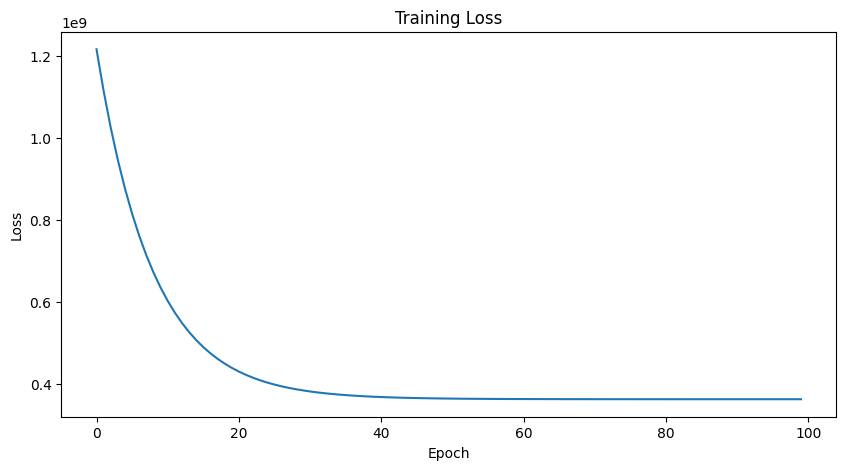

In [24]:
plt.figure(figsize=(10,5))

plt.plot(losses)

plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

In [25]:
test_loss, test_info = forward_linear_regression(
    X_test,
    y_test,
    weights
)

print(test_loss)

231243257.75633383


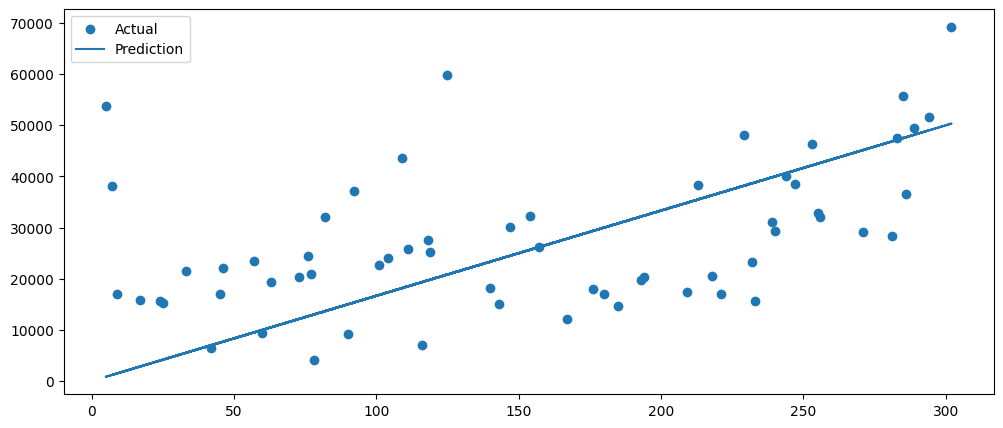

In [26]:
plt.figure(figsize=(12,5))

plt.scatter(X_test, y_test, label='Actual')

plt.plot(
    X_test,
    test_info['P'],
    label='Prediction'
)

plt.legend()

plt.show()

In [27]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
)

In [28]:
weights_torch = {
    'W': torch.randn((1,1), requires_grad=True),
    'B': torch.randn((1,1), requires_grad=True)
}

In [29]:
def forward_torch(X, y, weights):

    N = torch.matmul(X, weights['W'])

    P = N + weights['B']

    loss = torch.mean(
        (y.view(-1,1) - P) ** 2
    )

    return loss, P

In [30]:
optimizer = torch.optim.SGD(
    [weights_torch['W'], weights_torch['B']],
    lr=0.000001
)

In [31]:
losses_torch = []

for epoch in range(100):

    optimizer.zero_grad()

    loss, predictions = forward_torch(
        X_train_tensor,
        y_train_tensor,
        weights_torch
    )

    loss.backward()

    optimizer.step()

    losses_torch.append(loss.item())

    if epoch % 10 == 0:
        print(epoch, loss.item())

0 1208775936.0
10 600762624.0
20 429833088.0
30 381779776.0
40 368270112.0
50 364471712.0
60 363403328.0
70 363102496.0
80 363017408.0
90 362992992.0


In [32]:
import time
import functools

def timing(name):

    def decorator(func):

        @functools.wraps(func)
        def wrapper(*args, **kwargs):

            start = time.time()

            result = func(*args, **kwargs)

            print(
                f'[{name}] latency:',
                time.time() - start
            )

            return result

        return wrapper

    return decorator

In [33]:
@timing('forecast_pipeline')
def predict_sales():

    time.sleep(1)

    return 'done'

predict_sales()

[forecast_pipeline] latency: 1.0001287460327148


'done'

In [34]:
from concurrent.futures import ThreadPoolExecutor

def save_logs():
    return 'logs saved'

def analytics():
    return 'analytics sent'

def monitoring():
    return 'monitoring completed'

with ThreadPoolExecutor() as executor:

    results = executor.map(
        lambda f: f(),
        [
            save_logs,
            analytics,
            monitoring
        ]
    )

print(list(results))

['logs saved', 'analytics sent', 'monitoring completed']


In [35]:
!pip install nest-asyncio pyngrok

In [36]:
from fastapi import FastAPI
from pydantic import BaseModel
import nest_asyncio
from pyngrok import ngrok
import uvicorn

app = FastAPI()

class SalesInput(BaseModel):
    traffic: int
    ads_spend: int
    discount: int

@app.get('/')
def home():
    return {
        'message': 'Sales Forecast API'
    }

@app.post('/predict-sales')
def predict_sales(data: SalesInput):

    prediction = (
        data.traffic * 0.3 +
        data.ads_spend * 10 -
        data.discount * 5
    )

    return {
        'predicted_sales': prediction
    }

In [37]:
from pyngrok import ngrok

ngrok.set_auth_token("3Dfr6IRwIWzUYy85jTKLMBtMjSW_Tgta6UsCZpFsbXVZhP7m")

In [38]:
from pyngrok import ngrok
import nest_asyncio
import uvicorn

# aktifkan nested loop
nest_asyncio.apply()

# buat public url
public_url = ngrok.connect(8000)

print("PUBLIC URL:", public_url)

# jalankan server
config = uvicorn.Config(app, port=8000)
server = uvicorn.Server(config)

await server.serve()

INFO:     Started server process [2783]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


PUBLIC URL: NgrokTunnel: "https://repent-contrite-unelected.ngrok-free.dev" -> "http://localhost:8000"


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [2783]


In [39]:
import pickle

# save numpy weights
with open('sales_forecast_model.pkl', 'wb') as f:
    pickle.dump(weights, f)

print("MODEL SAVED")

MODEL SAVED


In [40]:
with open('sales_forecast_model.pkl', 'rb') as f:
    loaded_weights = pickle.load(f)

print(loaded_weights)

{'W': array([[166.54819668]]), 'B': array([[4.19205226]])}


In [41]:
def predict_sales(day_index, weights):

    X_input = np.array([[day_index]])

    prediction = (
        np.dot(X_input, weights['W']) +
        weights['B']
    )

    return prediction[0][0]

In [42]:
prediction = predict_sales(400, loaded_weights)

print("Predicted Sales:", prediction)

Predicted Sales: 66623.47072541264


In [43]:
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI()

class PredictionInput(BaseModel):
    day_index: int

@app.get('/')
def home():

    return {
        'message': 'AI Sales Forecast API'
    }

@app.post('/predict-sales')
def predict(data: PredictionInput):

    prediction = predict_sales(
        data.day_index,
        loaded_weights
    )

    return {
        'day_index': data.day_index,
        'predicted_sales': float(prediction)
    }

In [44]:
from pyngrok import ngrok
import nest_asyncio
import uvicorn

nest_asyncio.apply()

public_url = ngrok.connect(8000)

print("PUBLIC URL:", public_url)

config = uvicorn.Config(app, port=8000)
server = uvicorn.Server(config)

await server.serve()

PUBLIC URL: NgrokTunnel: "https://repent-contrite-unelected.ngrok-free.dev" -> "http://localhost:8000"


INFO:     Started server process [2783]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [2783]


In [45]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(message)s'
)

logging.info("MODEL STARTED")

In [46]:
@app.post('/predict-sales')
def predict(data: PredictionInput):

    logging.info(
        f'Prediction request: {data.day_index}'
    )

    prediction = predict_sales(
        data.day_index,
        loaded_weights
    )

    logging.info(
        f'Prediction result: {prediction}'
    )

    return {
        'day_index': data.day_index,
        'predicted_sales': float(prediction)
    }

In [47]:
import time
import functools

def monitor(name):

    def decorator(func):

        @functools.wraps(func)
        def wrapper(*args, **kwargs):

            start = time.time()

            result = func(*args, **kwargs)

            latency = time.time() - start

            print(
                f'[{name}] latency:',
                latency
            )

            return result

        return wrapper

    return decorator

In [48]:
@monitor('prediction_pipeline')
def predict_sales(day_index, weights):

    X_input = np.array([[day_index]])

    prediction = (
        np.dot(X_input, weights['W']) +
        weights['B']
    )

    return prediction[0][0]

In [49]:
from concurrent.futures import ThreadPoolExecutor

def save_logs():
    time.sleep(1)
    return 'logs saved'

def analytics():
    time.sleep(1)
    return 'analytics sent'

def monitoring():
    time.sleep(1)
    return 'monitoring completed'

with ThreadPoolExecutor() as executor:

    results = executor.map(
        lambda f: f(),
        [
            save_logs,
            analytics,
            monitoring
        ]
    )

print(list(results))

['logs saved', 'analytics sent', 'monitoring completed']


In [50]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 85.6 MB/s eta 0:00:00


In [51]:
%%writefile app.py

import streamlit as st
import numpy as np
import pickle

# load model
with open('sales_forecast_model.pkl', 'rb') as f:
    model = pickle.load(f)

st.title('AI Sales Forecast Dashboard')

day_index = st.slider(
    'Select Day Index',
    1,
    1000,
    100
)

prediction = (
    np.dot(
        np.array([[day_index]]),
        model['W']
    ) + model['B']
)

st.write(
    'Predicted Sales:',
    float(prediction[0][0])
)

Writing app.py


In [52]:
!streamlit run app.py &>/dev/null&

In [53]:
public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://repent-contrite-unelected.ngrok-free.dev" -> "http://localhost:8501"


In [54]:
import os

folders = [
    "data/raw",
    "data/processed",
    "model",
    "src",
    "app",
    "screenshots",
    "notebooks"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folder structure created!")

Folder structure created!


In [55]:
import shutil

shutil.move(
    "Online Retail.xlsx",
    "data/raw/Online Retail.xlsx"
)

print("Dataset moved!")

Dataset moved!


In [56]:
shutil.move(
    "sales_forecast_model.pkl",
    "model/sales_forecast_model.pkl"
)

print("Model moved!")

Model moved!


In [57]:
shutil.move(
    "app.py",
    "app/streamlit_app.py"
)

print("Streamlit app moved!")

Streamlit app moved!
